# MSE, MAE, and RMSE - Quick Revision Notes

These metrics tell us **how far predictions are from real values**. A smaller value is better.

## 1. Start with one error

$$error = y - \hat{y}$$

- $y$: real value, for example the real salary.
- $\hat{y}$: predicted value from the model.

If the real salary is 50 lakhs and the prediction is 47 lakhs, the error is $50 - 47 = 3$ lakhs. Error can be positive or negative, so the metrics below make every error positive before averaging.

## 2. Mean Absolute Error (MAE)

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

MAE means: **find each distance, ignore the plus/minus sign, then average.**

- It is easy to explain because it stays in the **same unit** as the target.
- Example: MAE = 2.5 lakhs means predictions are off by 2.5 lakhs on average.
- It is less affected by an outlier than MSE or RMSE.
- The absolute-value corner at zero is not differentiable, so optimization can use subgradients or other methods.

## 3. Mean Squared Error (MSE)

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

MSE means: **square each mistake, then average.**

- Squaring makes big mistakes much bigger. Error 2 becomes 4, but error 10 becomes 100.
- This is useful when large mistakes are especially bad.
- For ordinary linear regression, squared-error loss is smooth and convex in the model parameters, which makes it friendly for gradient-based optimization.
- It is very sensitive to outliers.
- Its unit is squared: a salary target in lakhs gives MSE in lakhs-squared, so it is harder to explain directly.

## 4. Root Mean Squared Error (RMSE)

$$RMSE = \sqrt{MSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

RMSE is the square root of MSE.

- Like MSE, it punishes large mistakes strongly.
- Unlike MSE, it returns to the **same unit** as the target.
- Example: RMSE = 3 lakhs means the typical error size is about 3 lakhs, with extra weight given to big mistakes.
- Minimizing MSE and minimizing RMSE give the same best model on the same data, because square root does not change which value is smallest.

## 5. Tiny worked example

Suppose the errors for four salary predictions are $2, 2, 3,$ and $4$ lakhs.

$$MAE = \frac{2+2+3+4}{4} = 2.75$$

$$MSE = \frac{2^2+2^2+3^2+4^2}{4} = 8.25$$

$$RMSE = \sqrt{8.25} \approx 2.87$$

MAE and RMSE are in lakhs. MSE is in lakhs-squared.

## 6. Which one should I use?

| Metric | Best simple use | Outlier effect | Unit |
|---|---|---|---|
| **MAE** | You want the average mistake to be easy to explain. | Lower | Same as target |
| **MSE** | Large mistakes should receive a very heavy penalty; common training loss. | High | Squared unit |
| **RMSE** | Large mistakes matter, but you want an answer in the target's unit. | High | Same as target |

In practice, look at more than one metric. A model can have a good average error but still make one very large mistake.

## Visual diagram

Run the next cell. Left: the green lines are prediction errors. The last red point is an outlier. Right: compare how a small error and a large error are treated by absolute error and squared error.

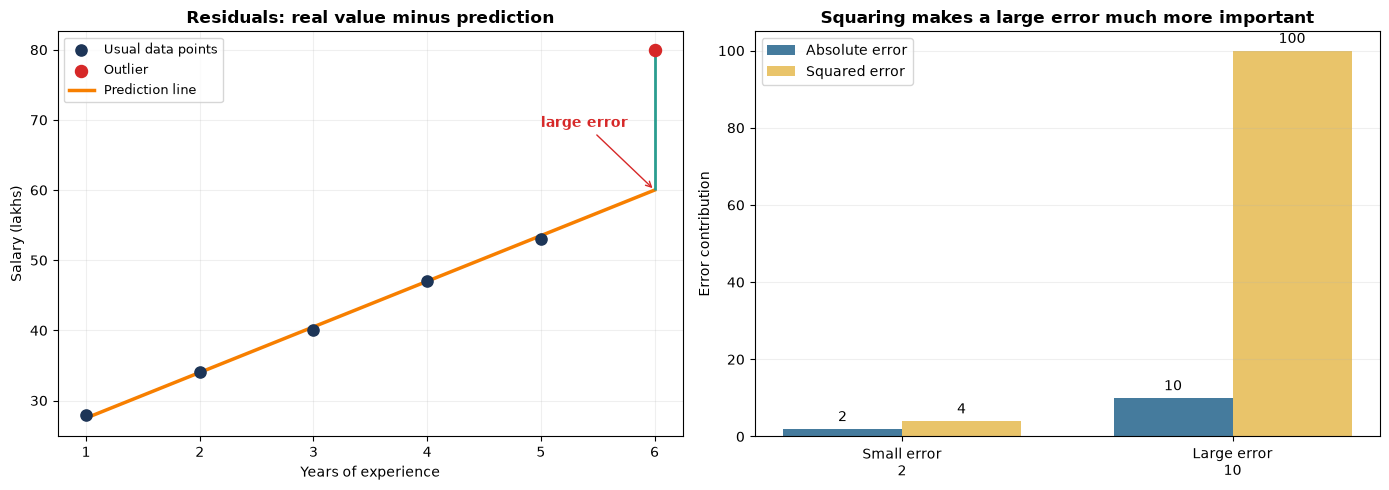

In [1]:
import numpy as np
import matplotlib.pyplot as plt

experience = np.array([1, 2, 3, 4, 5, 6])
actual_salary = np.array([28, 34, 40, 47, 53, 80])  # last point is an outlier
predicted_salary = 21 + 6.5 * experience

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: actual values, prediction line, and vertical residuals
ax = axes[0]
ax.scatter(experience[:-1], actual_salary[:-1], color='#1d3557', s=65, label='Usual data points', zorder=3)
ax.scatter(experience[-1], actual_salary[-1], color='#d62828', s=75, label='Outlier', zorder=3)
ax.plot(experience, predicted_salary, color='#f77f00', linewidth=2.5, label='Prediction line')
for x, real, pred in zip(experience, actual_salary, predicted_salary):
    ax.vlines(x, min(real, pred), max(real, pred), color='#2a9d8f', linewidth=2)
ax.annotate('large error', xy=(6, predicted_salary[-1]), xytext=(5.0, 69),
            arrowprops=dict(arrowstyle='->', color='#d62828'), color='#d62828', weight='bold')
ax.set_title('Residuals: real value minus prediction', weight='bold')
ax.set_xlabel('Years of experience')
ax.set_ylabel('Salary (lakhs)')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# Right: show why a large error has much more influence after squaring
errors = np.array([2, 10])
labels = ['Small error\n2', 'Large error\n10']
x = np.arange(len(errors))
width = 0.36
absolute_bars = axes[1].bar(x - width/2, errors, width, label='Absolute error', color='#457b9d')
squared_bars = axes[1].bar(x + width/2, errors**2, width, label='Squared error', color='#e9c46a')
axes[1].set_xticks(x, labels)
axes[1].set_ylabel('Error contribution')
axes[1].set_title('Squaring makes a large error much more important', weight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.2)
for bars in [absolute_bars, squared_bars]:
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                     f'{bar.get_height():.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


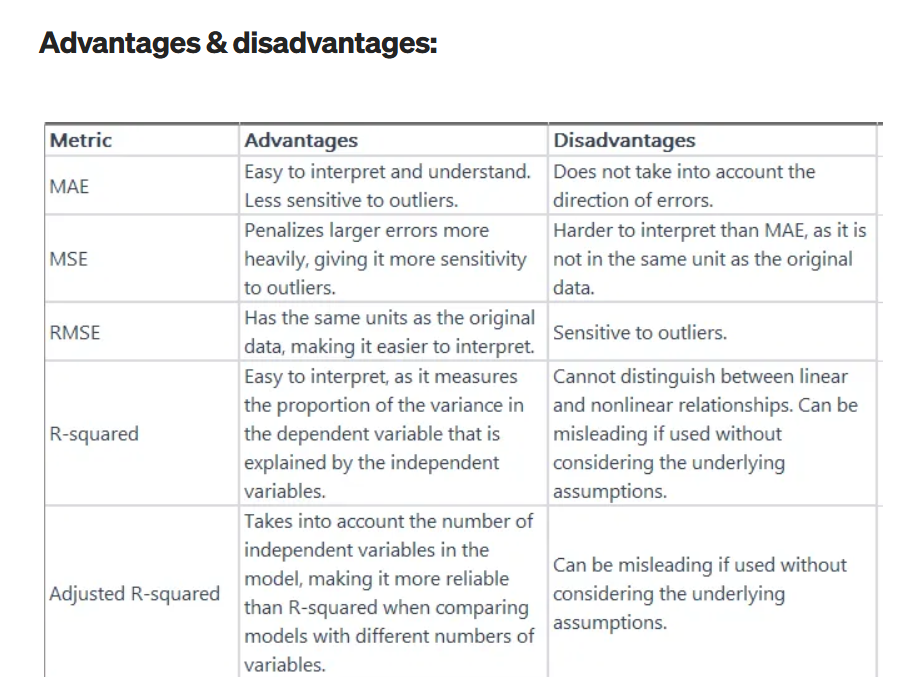

## 7. Exam-ready recap

- MAE = average absolute mistake; easy to understand and less sensitive to outliers.
- MSE = average squared mistake; strongly punishes big mistakes and is common for training regression models.
- RMSE = square root of MSE; it also punishes big mistakes but returns to the target's original unit.

**One-line answer:** Use MAE when a typical error should be easy to explain; use RMSE when big errors are especially important and you want the answer in the original unit.